Nome: Rafael Andre Alves de Siqueira

RA: 243360

Curso: Engenharia de Computação



# Ex02 - Histograma e Extração de Características

Esta atividade tem 2 objetivos principais:
  - Entender o conceito de histograma e estatísticas da imagem;
  - Explorar diferentes formas de extração de características em histogramas e sua aplicação em um problema de classificação.

In [ ]:
# Importando as bibliotecas que serão utilizadas
from io import BytesIO
import os
import random

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageFile
import requests
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier

## Parte 1 - Histograma

Leia o notebook [Histograma de imagens](https://github.com/lrittner/Computacao-Visual/blob/master/tutoriais/05_Histograma_da_imagem.ipynb) para entender o conceito de histograma e o uso da função *np.histogram*. Tente também entender a função a seguir, que plota o histograma usando gráfico de barras. Essa função será muito útil nos exercícios deste notebook.

In [ ]:
def plota_hist(h,cor,nbins,bin_edges):

    w=255./nbins
    bin_centers = bin_edges[1:]-(w/2)
    plt.bar(bin_centers, h, width=w, color=cor)

### Exercício 1.1

Vamos tentar calcular o histograma de imagens coloridas. Para isso, utilize as imagens tiradas durante o dia ou durante a noite, lidas e apresentadas pelo código abaixo. Observe que elas estão na lista `all_imgs`, sendo a primeira metade as imagens de dia, e a segunda as imagens de noite.

Plote os histogramas de cada uma das bandas das imagens usando gráficos de barras (função `plota_hist`). Compare visualmente os histogramas e comente as principais diferenças observadas. Se você tivesse que dizer quais histogramas pertencem a quais classes de imagem (dia ou noite), você seria capaz de acertar? Explique porque.

In [ ]:
def read_image_url(url:str) -> np.ndarray:
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    img = np.array(img)

    return img

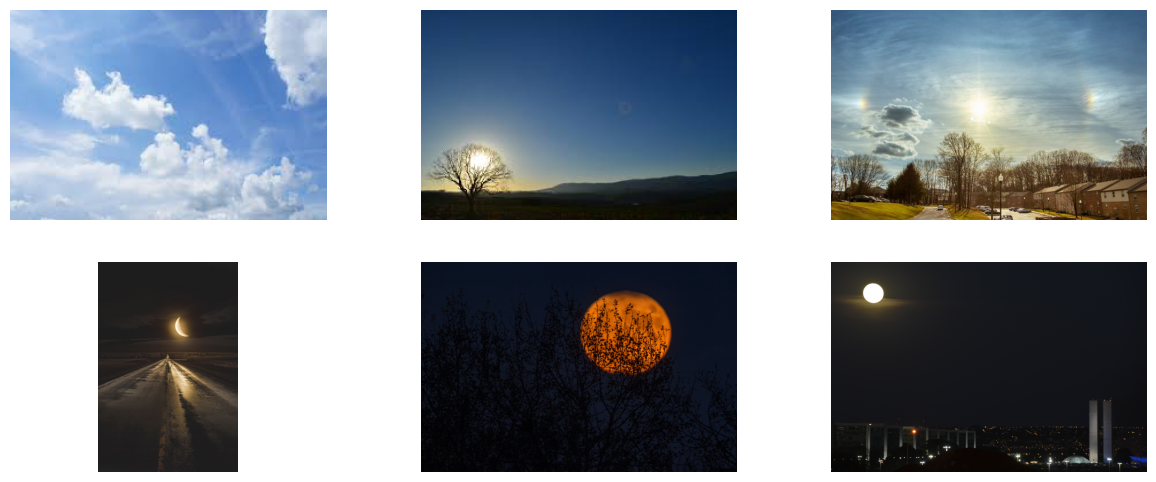

In [ ]:
base_path = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/refs/heads/main/imgs/{img_name}.jpg"

fig, axs = plt.subplots(2,3,figsize=(15, 6))

all_imgs = []

index = 0
for daytime in ["dia", "noite"]:

  for i in range(3):
    img_name = daytime+"_"+str(i+1)
    img = read_image_url(base_path.format(img_name=img_name))
    all_imgs.append(img)

    plt.subplot(2,3,1+index)
    plt.axis('off')
    plt.imshow(img)

    index += 1

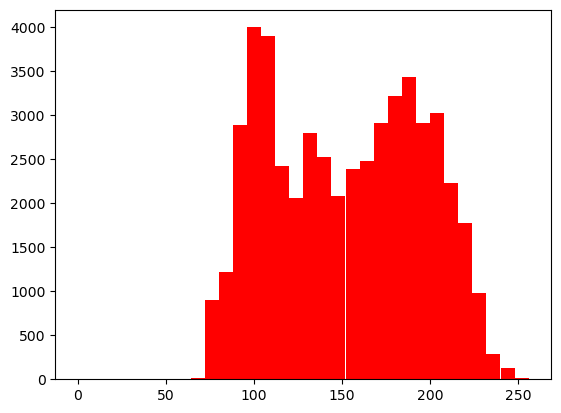

In [ ]:
# Seu código aqui
img = all_imgs[0]
canal_vermelho = img[:,:,0]
nbins = 32 # Use um número menor de bins para o gráfico de barras ficar legível
h, bin_edges = np.histogram(canal_vermelho, bins=nbins, range=(0, 256))

plota_hist(h, 'red', nbins, bin_edges)


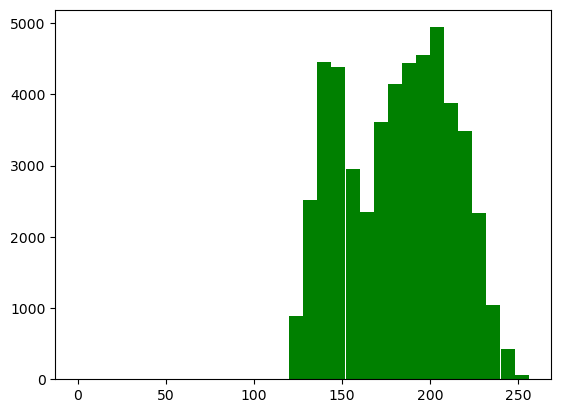

In [ ]:
# Seu código aqui
img = all_imgs[0]
canal_verde = img[:, :, 1]
nbins = 32 # Use um número menor de bins para o gráfico de barras ficar legível

h, bin_edges = np.histogram(canal_verde, bins=nbins, range=(0, 256))

plota_hist(h, 'green', nbins, bin_edges)

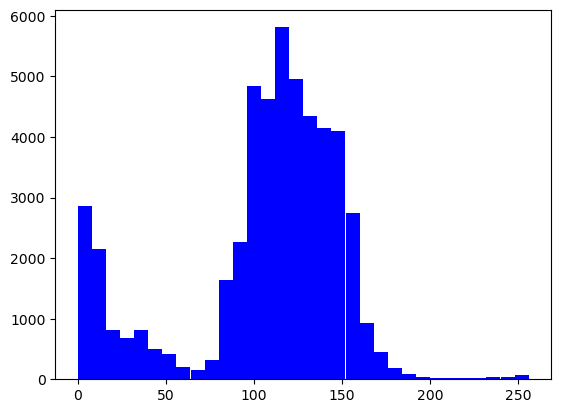

In [ ]:
# Seu código aqui
img = all_imgs[0]
canal_verde = img[:, :, 2]
nbins = 32 # Use um número menor de bins para o gráfico de barras ficar legível

h, bin_edges = np.histogram(canal_azul, bins=nbins, range=(0, 256))

plota_hist(h, 'blue', nbins, bin_edges)

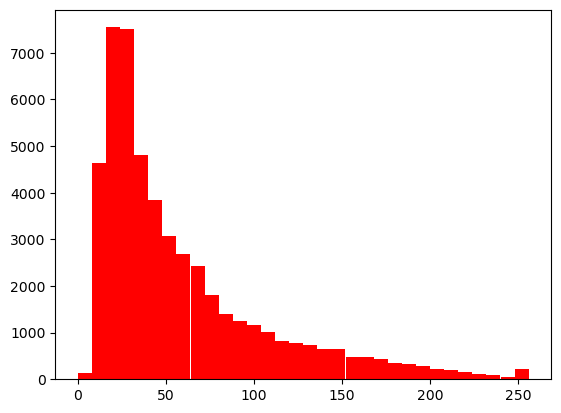

In [ ]:
img = all_imgs[1]
canal_vermelho = img[:,:,0]
nbins = 32 # Use um número menor de bins para o gráfico de barras ficar legível
h, bin_edges = np.histogram(canal_vermelho, bins=nbins, range=(0, 256))

plota_hist(h, 'red', nbins, bin_edges)

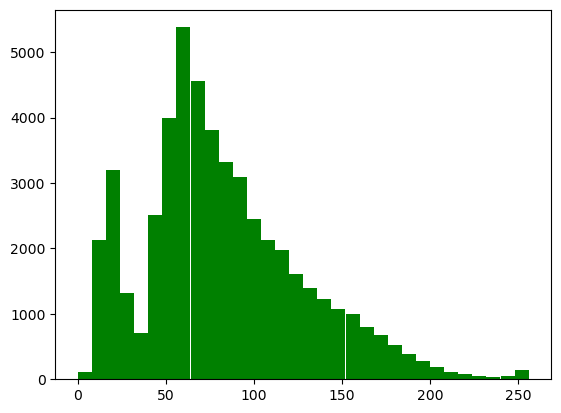

In [ ]:
img = all_imgs[1]
canal_verde = img[:,:,1]
nbins = 32 # Use um número menor de bins para o gráfico de barras ficar legível
h, bin_edges = np.histogram(canal_verde, bins=nbins, range=(0, 256))

plota_hist(h, 'green', nbins, bin_edges)

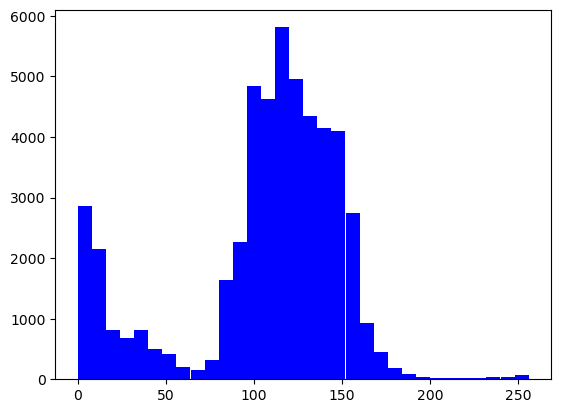

In [ ]:
img = all_imgs[1]
canal_azul = img[:,:,2]
nbins = 32 # Use um número menor de bins para o gráfico de barras ficar legível
h, bin_edges = np.histogram(canal_azul, bins=nbins, range=(0, 256))

plota_hist(h, 'blue', nbins, bin_edges)

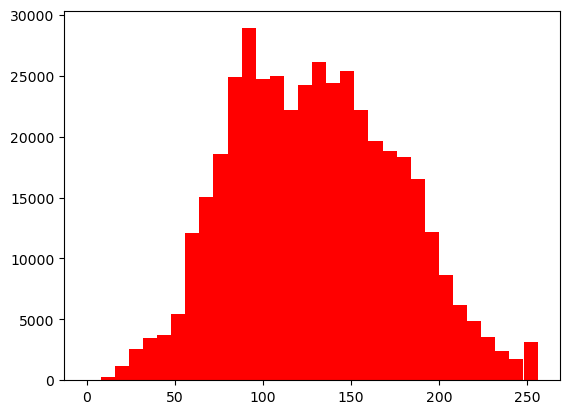

In [ ]:
img = all_imgs[2]
canal_vermelho = img[:,:,0]
nbins = 32 # Use um número menor de bins para o gráfico de barras ficar legível
h, bin_edges = np.histogram(canal_vermelho, bins=nbins, range=(0, 256))

plota_hist(h, 'red', nbins, bin_edges)

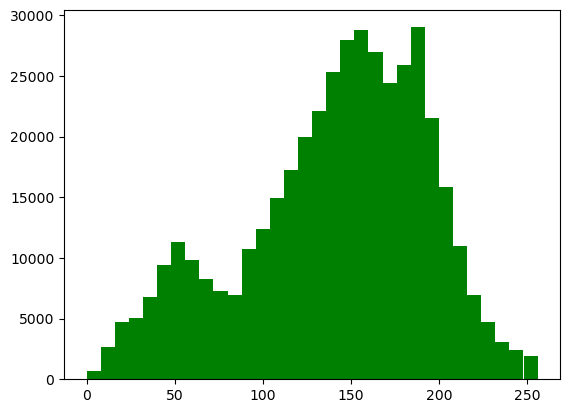

In [ ]:
img = all_imgs[2]
canal_verde = img[:,:,1]
nbins = 32 # Use um número menor de bins para o gráfico de barras ficar legível
h, bin_edges = np.histogram(canal_verde, bins=nbins, range=(0, 256))

plota_hist(h, 'green', nbins, bin_edges)

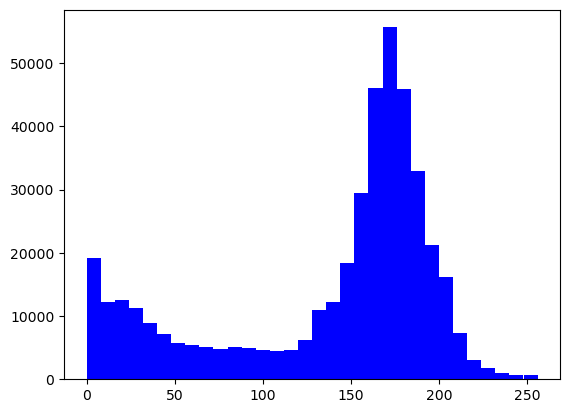

In [ ]:
img = all_imgs[2]
canal_azul = img[:,:,2]
nbins = 32 # Use um número menor de bins para o gráfico de barras ficar legível
h, bin_edges = np.histogram(canal_azul, bins=nbins, range=(0, 256))

plota_hist(h, 'blue', nbins, bin_edges)

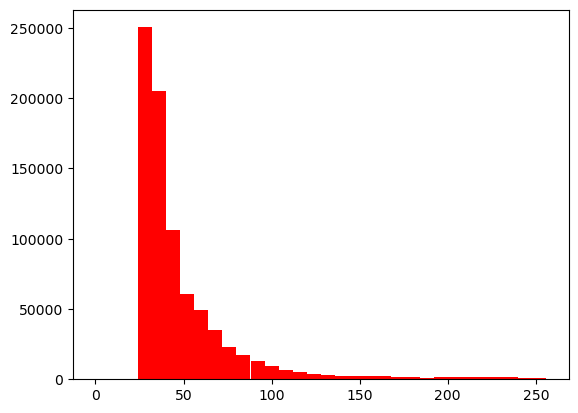

In [ ]:
img = all_imgs[3]
canal_vermelho = img[:,:,0]
nbins = 32 # Use um número menor de bins para o gráfico de barras ficar legível
h, bin_edges = np.histogram(canal_vermelho, bins=nbins, range=(0, 256))

plota_hist(h, 'red', nbins, bin_edges)

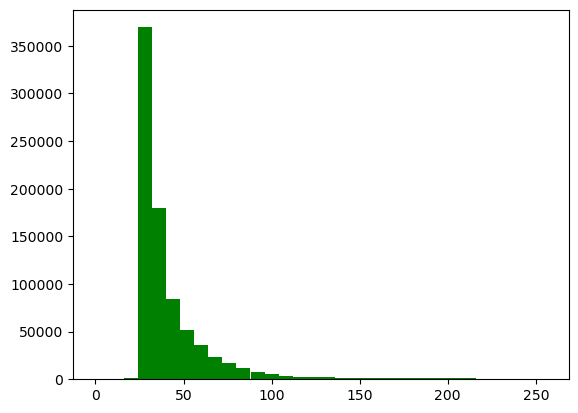

In [ ]:
img = all_imgs[3]
canal_verde = img[:,:,1]
nbins = 32 # Use um número menor de bins para o gráfico de barras ficar legível
h, bin_edges = np.histogram(canal_verde, bins=nbins, range=(0, 256))

plota_hist(h, 'green', nbins, bin_edges)

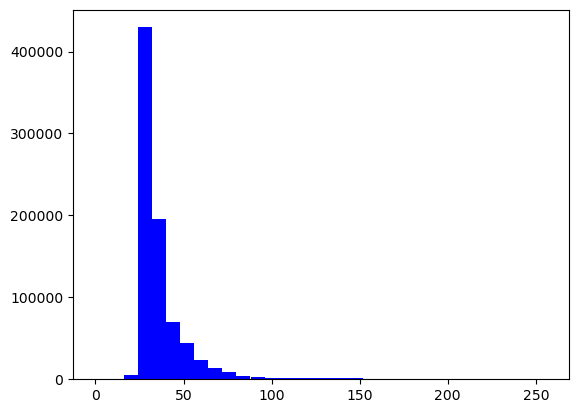

In [ ]:
img = all_imgs[3]
canal_azul = img[:,:,2]
nbins = 32 # Use um número menor de bins para o gráfico de barras ficar legível
h, bin_edges = np.histogram(canal_azul, bins=nbins, range=(0, 256))

plota_hist(h, 'blue', nbins, bin_edges)

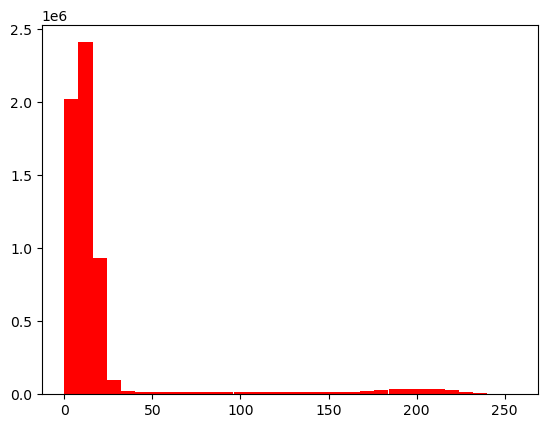

In [ ]:
img = all_imgs[4]
canal_vermelho = img[:,:,0]
nbins = 32 # Use um número menor de bins para o gráfico de barras ficar legível
h, bin_edges = np.histogram(canal_vermelho, bins=nbins, range=(0, 256))

plota_hist(h, 'red', nbins, bin_edges)

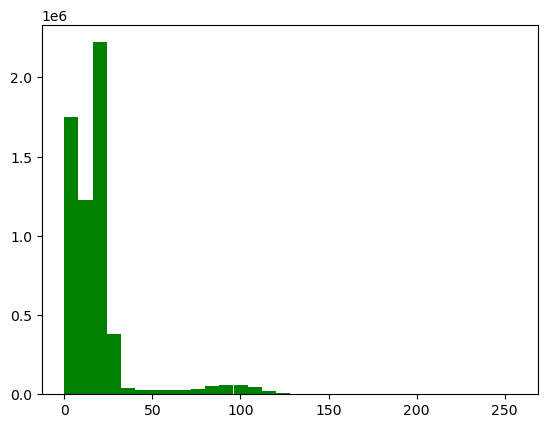

In [ ]:
img = all_imgs[4]
canal_verde = img[:,:,1]
nbins = 32 # Use um número menor de bins para o gráfico de barras ficar legível
h, bin_edges = np.histogram(canal_verde, bins=nbins, range=(0, 256))

plota_hist(h, 'green', nbins, bin_edges)

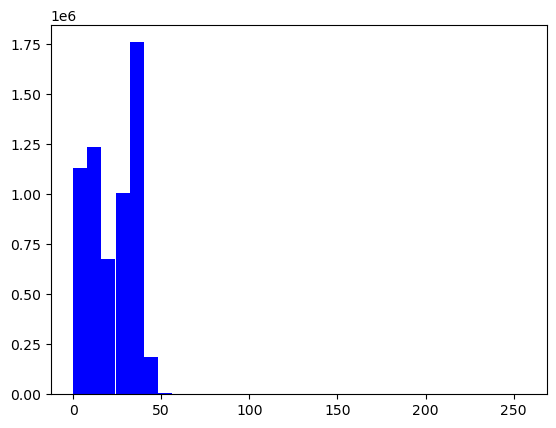

In [ ]:
img = all_imgs[4]
canal_azul = img[:,:,2]
nbins = 32 # Use um número menor de bins para o gráfico de barras ficar legível
h, bin_edges = np.histogram(canal_azul, bins=nbins, range=(0, 256))

plota_hist(h, 'blue', nbins, bin_edges)

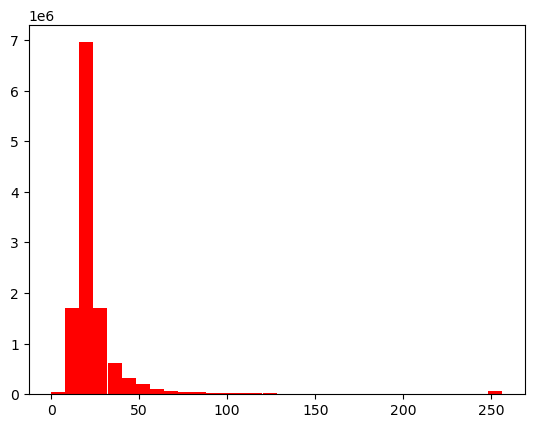

In [ ]:
img = all_imgs[5]
canal_vermelho = img[:,:,0]
nbins = 32 # Use um número menor de bins para o gráfico de barras ficar legível
h, bin_edges = np.histogram(canal_vermelho, bins=nbins, range=(0, 256))

plota_hist(h, 'red', nbins, bin_edges)

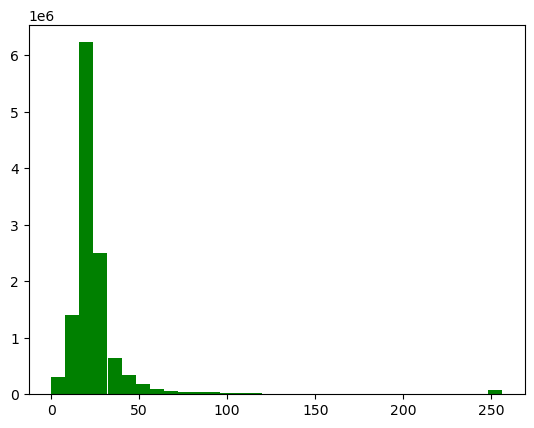

In [ ]:
img = all_imgs[5]
canal_verde = img[:,:,1]
nbins = 32 # Use um número menor de bins para o gráfico de barras ficar legível
h, bin_edges = np.histogram(canal_verde, bins=nbins, range=(0, 256))

plota_hist(h, 'green', nbins, bin_edges)

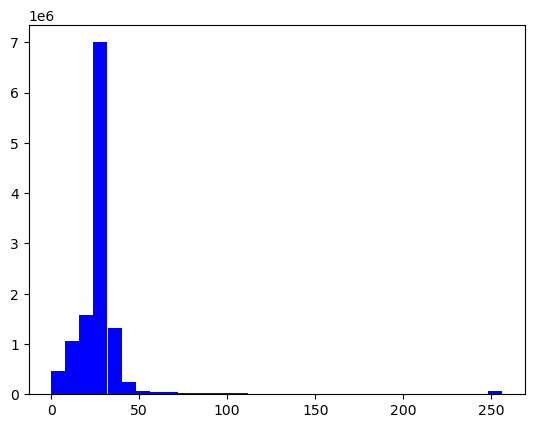

In [ ]:
img = all_imgs[5]
canal_azul = img[:,:,2]
nbins = 32 # Use um número menor de bins para o gráfico de barras ficar legível
h, bin_edges = np.histogram(canal_azul, bins=nbins, range=(0, 256))

plota_hist(h, 'blue', nbins, bin_edges)

Principais diferenças: Os de noite tem maior concentração de pixels nas baixas frequências dos canais RGB, já os de dia tem uma distribuição mais normal ao longo das frequências. Seria capaz de acertar sim pois os de noite tem histogramas concentrados entre 0 e 50 nos canais RGB.

### Exercício 1.2

Selecione duas imagens coloridas do item anterior (uma de dia e uma de noite) e faça a conversão para níveis de cinza, usando os métodos abaixo:
   - médias das bandas R, G, B;
   - média ponderada das bandas R, G, B: procure qual a poderação mais utilizada;
   - convert(L) da biblioteca PIL (utilize `Image.fromarray(array)` para converter o array para uma imagem do PIL);

Em seguida, calcule o histograma das imagens convertidas para níveis de cinza. Compare os histogramas em níveis de cinza e discuta novamente as diferenças.   

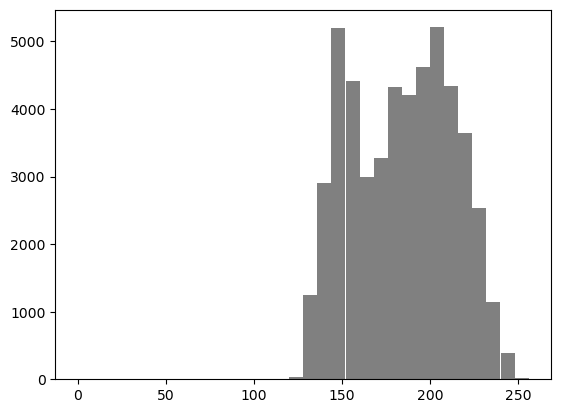

In [ ]:
# Seu código aqui
img_dia = all_imgs[0]
img_noite = all_imgs[3]
img=img_dia
cinza_media = np.mean(img, axis=2).astype(np.uint8)
cinza_ponderada = (0.299 * img[:,:,0] + 0.587 * img[:,:,1] + 0.114 * img[:,:,2]).astype(np.uint8)
img_pil = Image.fromarray(img.astype(np.uint8))
cinza_pil = np.array(img_pil.convert('L'))


h, bin_edges = np.histogram(cinza_media, bins=nbins, range=(0, 256))
nbinds =32
plota_hist(h, 'grey', nbins, bin_edges)


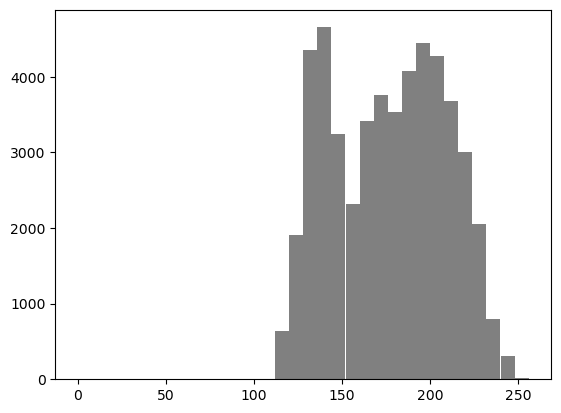

In [ ]:
# Seu código aqui
img_dia = all_imgs[0]
img_noite = all_imgs[3]
img=img_dia
cinza_media = np.mean(img, axis=2).astype(np.uint8)
cinza_ponderada = (0.299 * img[:,:,0] + 0.587 * img[:,:,1] + 0.114 * img[:,:,2]).astype(np.uint8)
img_pil = Image.fromarray(img.astype(np.uint8))
cinza_pil = np.array(img_pil.convert('L'))


h, bin_edges = np.histogram(cinza_ponderada, bins=nbins, range=(0, 256))
nbinds =32
plota_hist(h, 'grey', nbins, bin_edges)

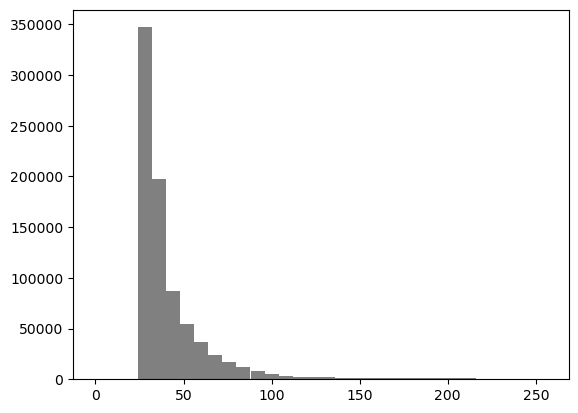

In [ ]:
# Seu código aqui
img_dia = all_imgs[0]
img_noite = all_imgs[3]
img=img_noite
cinza_media = np.mean(img, axis=2).astype(np.uint8)
cinza_ponderada = (0.299 * img[:,:,0] + 0.587 * img[:,:,1] + 0.114 * img[:,:,2]).astype(np.uint8)
img_pil = Image.fromarray(img.astype(np.uint8))
cinza_pil = np.array(img_pil.convert('L'))


h, bin_edges = np.histogram(cinza_media, bins=nbins, range=(0, 256))
nbinds =32
plota_hist(h, 'grey', nbins, bin_edges)

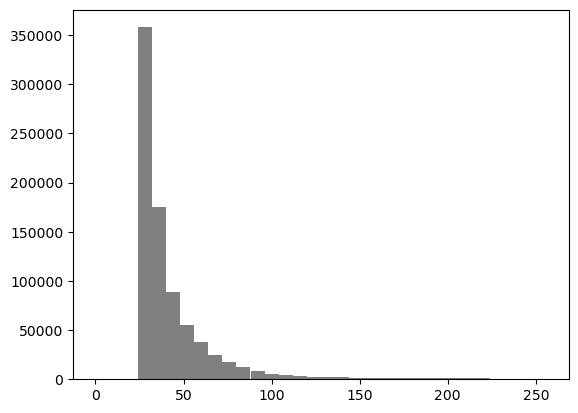

In [ ]:
# Seu código aqui
img_dia = all_imgs[0]
img_noite = all_imgs[3]
img=img_noite
cinza_media = np.mean(img, axis=2).astype(np.uint8)
cinza_ponderada = (0.299 * img[:,:,0] + 0.587 * img[:,:,1] + 0.114 * img[:,:,2]).astype(np.uint8)
img_pil = Image.fromarray(img.astype(np.uint8))
cinza_pil = np.array(img_pil.convert('L'))


h, bin_edges = np.histogram(cinza_ponderada, bins=nbins, range=(0, 256))
nbinds =32
plota_hist(h, 'grey', nbins, bin_edges)

Os histogramas da imagem de dia tem uma distribuição aproximadamente normal ao redor de 200, já os de noite tem uma distribuição concentrada entre 25 e 100. Entre a média simples e a média ponderada, praticamente não muda, exceto por algumas frequências, que ficam ligeiramente mais frequentes ou menos.

## Parte 2 - Extraindo atributos derivados do histograma

Histogramas podem ser utilizados para extrair atributos de imagens. Estes dados são úteis em tarefas de aprendizado de máquina, como a classificação de imagens.

Dentre os atribitos mais comuns usados para a classificação de imagens, estão: *média*, *variância*, *assimetria* e *curtose*.

A função abaixo calcula, dada uma imagem em níveis de cinza, o histograma e seus atributos. Além dos atributos listados acima, ela também calcula os percentis 1, 10, 50, 90 e 99%.

In [ ]:
def histstat(f):

    h, bin_edges = np.histogram(f, 256, (0,255))
    hn = 1.0*h/h.sum() # compute the normalized image histogram
    cum_hn = np.cumsum(hn) # compute the cumulative image histogram
    v = np.zeros(9) # number of statistics

    # compute statistics
    n = len(h) # number of gray values
    v[0]  = np.sum((np.arange(n)*hn)) # mean
    v[1]  = np.sum(np.power((np.arange(n)-v[0]),2)*hn) # variance
    v[2]  = np.sum(np.power((np.arange(n)-v[0]),3)*hn)/(np.power(v[1],1.5)) # skewness
    v[3]  = np.sum(np.power((np.arange(n)-v[0]),4)*hn)/(np.power(v[1],2))-3 # kurtosis
    v[4] = np.where(cum_hn >= 0.01)[0][0] # 1% percentile
    v[5] = np.where(cum_hn >= 0.1)[0][0] # 10% percentile
    v[6] = np.where(cum_hn >= 0.5)[0][0] # 50% percentile
    v[7] = np.where(cum_hn >= 0.9)[0][0] # 90% percentile
    v[8] = np.where(cum_hn >= 0.99)[0][0] # 99% percentile

    return v

Se quisermos então extrair os atributos de histograma de uma das imagens tiradas durante o dia, basta fazermos:

In [ ]:
f = all_imgs[0]
f_gray = np.uint8(0.3*f[:,:,0]+0.59*f[:,:,1]+0.11*f[:,:,2]) # Conversão para níveis de cinza
hist_features = histstat(f_gray)
for feature in hist_features:
  print(f'{feature:.2f}')

175.75
,1035.83
,-0.03
,-1.11
,118.00
,132.00
,178.00
,218.00
,237.00


### Exercício 2.1

Extraia agora os atributos de uma das imagens tiradas durante a noite e compare com os atributos da imagem anterior. Eles parecem suficientemente diferentes para distinguir uma da outra?

In [ ]:
# Seu código aqui
f = all_imgs[3]
f_gray = np.uint8(0.3*f[:,:,0]+0.59*f[:,:,1]+0.11*f[:,:,2]) # Conversão para níveis de cinza
hist_features = histstat(f_gray)
for feature in hist_features:
  print(f'{feature:.2f}')

43.47
704.19
3.65
16.82
28.00
29.00
33.00
69.00
179.00


média, variância, skewness, kurtosis, 1%perc, 10% perc, 50% perc, 90% perc, 99% perc
A imagem da noite tem uma menor média, indicando menor luminosidade. A do dia tem maior variância, indicando uma distribuição mais homogênea. O 1% percentil da noite é menor, o que indica que os 1% pixels mais escuros são mais escuros que os do dia. O mesmo vale para o 10% percentil, 50% percentil, 90% percentil e 99% percentil. Portanto estes atributos da iamgem são suficientemente diferentes para distinguir as duas imagens.

## Parte 3 - Classificação de imagens utilizando atributos derivados do histograma

### O classificador dos K-vizinhos mais próximos (KNN ou K-Nearest Neighbors)

[KNN (K-Nearest Neighbors)](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) é um algoritmo de classificação que usa uma abordagem baseada em instâncias, ou seja, ele classifica uma nova amostra com base nas amostras mais próximas (vizinhas) a ela. O KNN se baseia na suposição de que amostras próximas no espaço de atributos estão mais propensas a pertencer à mesma classe.

Para classificar imagens usando o algoritmo KNN, primeiro o conjunto de dados de treinamento é utilizado para construir uma representação dos dados que permita a busca dos vizinhos mais próximos.

Em seguida, para classificar uma nova amostra, o algoritmo encontra as K amostras mais próximas na representação construída, em que K é um parâmetro definido pelo usuário.

Por fim, a classe da nova amostra é determinada pela classe mais comum entre os vizinhos encontrados.



### Exemplo de uso do KNN:

Um conjunto de dados de duas classes é gerado aleatoriamente e, em seguida, o modelo KNN é treinado com k=5 vizinhos próximos. Note que a função **KNeighborsClassifier()** foi importada da biblioteca **sklearn.neighbors** e foi utilizada para criar o modelo KNN. A função *fit()* foi utilizada para treinar o modelo

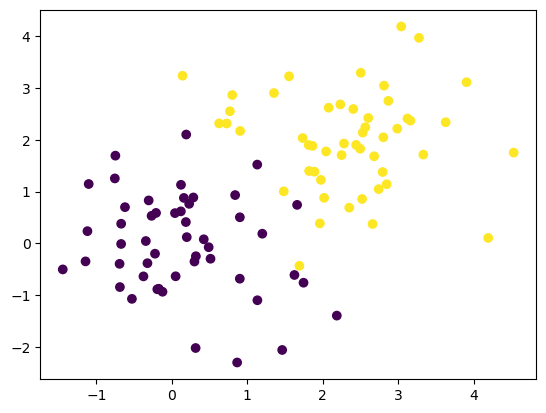

In [ ]:
# Geração de dados aleatórios
np.random.seed(1)
X1 = np.random.randn(50, 2)  # 50 amostras da classe 1
X2 = np.random.randn(50, 2) + 2  # 50 amostras da classe 2
X = np.concatenate((X1, X2))
Y = np.concatenate((np.zeros(50), np.ones(50))) # rótulos das classes (0 e 1)

# Visualizando as amostras (coloridas por classe)
plt.scatter(X[:,0],X[:,1],c=Y)
plt.show()

# Criando o modelo KNN
model = KNeighborsClassifier(n_neighbors=5)

# Treinando o modelo
model.fit(X, Y);

Em seguida, novas amostras aleatórias foram criadas para teste e o modelo foi utilizado para classificá-las.

A função *predict()* é utilizada para classificar as novas amostras.



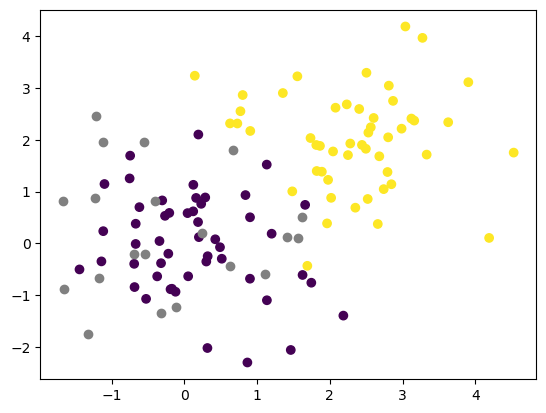

In [ ]:
# Criando novas amostras aleatórias para teste
X_test = np.random.randn(20, 2)

#  Visualizando o conjunto de teste
plt.scatter(X[:,0],X[:,1],c=Y)
plt.scatter(X_test[:,0],X_test[:,1],c='gray')
plt.show()

# Classificando as amostras
Y_test_pred = model.predict(X_test)

Para avaliar a qualidade de um classificador, normalmente se utiliza as seguintes métricas:

- [Acurácia (accuracy_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html): mede a proporção de amostras classificadas corretamente pelo modelo.
- [Precisão (precision_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html): mede a proporção de amostras classificadas como positivas (1) que são realmente positivas.
- [Recall (recall_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html): mede a proporção de amostras positivas (1) que são corretamente identificadas pelo modelo.
- [F1-Score (f1_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html): média harmônica entre precisão e recall.

Note que estas não são as únicas métricas utilizadas para avaliar um classificador. A escolha das métricas depende do contexto e dos objetivos da classificação. Na medicina, por exemplo, costuma-se utilizar a sensibilidade (ou recall) e a especificidade (mede a proporção de amostras negativas (0) que são corretamente identificadas pelo modelo). Dessa forma, pode-se determinar em que medida o classificador/exame é sensível à condição em questão (detecta corretamente as amostras positivas) e específico para detectar apenas ela (detecta corretamente as amostras negativas).

**Atenção**: para avaliar o modelo, as métricas foram calculadas em relação às amostras de treinamento, o que **não** é o ideal em um cenário real de classificação. No entanto, para fins didáticos, pode-se utilizar essas métricas para avaliar o desempenho do modelo.

In [ ]:
# Avaliando o modelo (as funções foram importadas previamente da biblioteca sklearn.metrics)
acc = accuracy_score(Y, model.predict(X))
prec = precision_score(Y, model.predict(X))
rec = recall_score(Y, model.predict(X))
f1 = f1_score(Y, model.predict(X))

# Imprimindo as métricas
print('Acurácia: %.2f' % acc)
print('Precisão: %.2f' % prec)
print('Recall: %.2f' % rec)
print('F1-Score: %.2f' % f1)

Acurácia: 0.96
,Precisão: 0.94
,Recall: 0.98
,F1-Score: 0.96


Para fazer uma avaliação qualitativa do classificador, podemos plotar os resultados da classificação utilizando a função [scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) do matplotlib. As amostras de treinamento são plotadas com pontos circulares, enquanto as amostras de teste são plotadas com pontos cruzados.


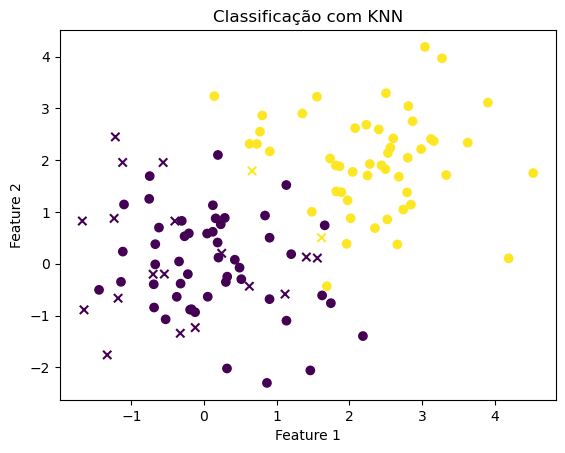

In [ ]:
# Plotando os resultados
plt.scatter(X[:, 0], X[:, 1], c=Y)
plt.scatter(X_test[:, 0], X_test[:, 1], marker='x', c=Y_test_pred)
plt.title('Classificação com KNN')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

### Exercício 3.1

Vamos agora usar o mesmo classificador KNN para classificar imagens, utilizando um dataset de imagens dermatoscópicas de lesões de pele comuns.

**Dataset**

O dataset consiste em 500 imagens de lesões de pele, obtidas ao longo de 20 anos em dois hospitais diferentes. Como as imagens foram obtidas e armazenadas de diferentes formas ao longo do tempo (armazenadas em arquivos PowerPoint, por exemplo), elas passaram por um processo de seleção, organização e padronização para compor o dataset. Assim, as imagens foram cortadas em torno das lesões de modo a deixá-las centralizadas e, em alguns casos, tiveram seus histogramas corrigidos manualmente para melhorar o contraste visual e a reprodução de cores.

As imagens estão divididas em dois tipos de lesão de pele:
- 250 casos de carcinoma basocelular (label 0) - um tipo de câncer de pele que começa nas células basais, raramente apresenta metástase, mas cresce de forma destrutiva se não tratado;
- 250 casos de melanoma (label 1) - o tipo mais grave de câncer de pele, que começa nas células produtoras de melanina, é quase sempre curável em estágios iniciais, mas tende a apresentar metástase com o tempo.

**Classificação**

O dataset está separado em um conjunto de treino com 400 imagens (200 de cada classe) e um conjunto de teste com 100 imagens (50 de cada classe).

Neste caso, ao invés de utilizar dados aleatórios para treinamento e teste, vamos extrair os atributos dos histogramas dos conjuntos de imagens. Os atributos serão utilizadas como dados de entrada do modelo. As imagens devem ser classificadas em 0 ou 1, representando os dois tipos de lesões presentes no dataset (carcinoma ou melanoma, respectivamente).

O código abaixo cria os conjuntos de treino e teste (imagens e labels) utilizando as imagens disponíveis no dataset.

In [4]:
try:
    from medmnist import DermaMNIST
except:
    !pip install medmnist
    from medmnist import DermaMNIST


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.4 MB/s eta 0:00:00


In [5]:
train_dataset = DermaMNIST(
    split="train",
    download=True
)

test_dataset = DermaMNIST(
    split="test",
    download=True
)

#1 = carcinoma -> 0
#4 = melanoma -> 1

100%|██████████| 19.7M/19.7M [00:15<00:00, 1.27MB/s]


In [6]:
images_train = []
labels_train = []
images_test = []
labels_test = []

datasets = {"train":train_dataset, "test":test_dataset}
img_count = {"train":200, "test":50}
images : dict[str, list[np.ndarray]] = {}
labels : dict[str, list[int]] = {}

for split in datasets:
    dataset = datasets[split]
    images[split] = []
    labels[split] = []

    counter = {0:0, 1:0}

    for data in dataset:
        img = data[0]
        label = data[1].item()
        if label == 1:
            label = 0
        elif label == 4:
            label = 1
        else:
            continue

        if counter[label] >= img_count[split]:
            continue

        images[split].append(np.array(img))
        labels[split].append(label)

        counter[label] += 1



images_train = images["train"]
labels_train = labels["train"]
images_test = images["test"]
labels_test = labels["test"]


print(f'labels_train: \n{labels_train}')
print('Número de imagens de treino:', len(labels_train))

print(f'labels_test: \n{labels_test}')
print('Número de imagens de teste:', len(labels_test))

labels_train: 
[1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

Agora, vamos visualizar algumas imagens do dataset. O código abaixo seleciona e plota quatro imagens aleatórias de cada classe do conjunto de treino. Tente executá-lo algumas vezes e comparar as duas classes visualmente.

In [7]:
images_train[random.randint(0,199)]
images_train[random.randint(200,399)]

n_imgs = 4
fig, axs = plt.subplots(2,n_imgs,figsize=(8, 4))

for n in range(n_imgs):
  plt.subplot(2,n_imgs,n+1)
  plt.axis('off')
  tmp = random.randint(0,199)
  plt.imshow(images_train[tmp])
  plt.title(f'Classe {labels_train[tmp]}')

  plt.subplot(2,n_imgs,n+n_imgs+1)
  plt.axis('off')
  tmp = random.randint(200,399)
  plt.imshow(images_train[tmp])
  plt.title(f'Classe {labels_train[tmp]}')

NameError: name 'random' is not defined

**a)** Crie uma função que receba um conjunto de imagens RGB, transforme as imagens em *grayscale*, e extraia os atributos do histograma de cada imagem. A função deve retornar os atributos dos histogramas concatenados em um vetor de atributos. Utilize a função **"histstat"** dada nesse notebook para extração de atributos.

Utilize os conjuntos de dados criados anteriormente para obter os vetores de atributos das amostras de treino e teste (train_features e test_features).

**Atenção!** Para o conjunto de treino você deve obter uma matriz 400 x 9, onde cada linha corresponde a uma amostra (imagem) e cada coluna correponde a um atributo do histograma. Da mesma forma, para o conjunto de teste você deve obter uma matriz 100 x 9.

In [8]:
import numpy as np

def histstat(h):
    """
    Calcula estatísticas de um histograma h.
    Retorna um vetor com 9 atributos estatísticos.
    """
    p = h / np.sum(h)
    L = len(h)
    v = np.arange(L)

    mu = np.sum(v * p)

    v_mu = v - mu
    sigma2 = np.sum((v_mu**2) * p)
    std = np.sqrt(sigma2)

    if std <= 0:
        skew = 0
    else:
        skew = np.sum((v_mu**3) * p) / (std**3)

    kurt = np.sum((v_mu**4) * p) / (sigma2**2 + 1e-10)
    energy = np.sum(p**2)
    entropy = -np.sum(p * np.log2(p + 1e-10))

    smooth = 1 - (1 / (1 + sigma2))

    max_prob = np.max(p)

    return np.array([mu, std, skew, kurt, energy, entropy, smooth, max_prob, sigma2])

def extrair_features_dataset(lista_imagens):
    """
    Transforma imagens RGB em Grayscale e extrai atributos do histograma.
    Retorna uma matriz (N x 9).
    """
    features = []

    for img_rgb in lista_imagens:
        img_gray = np.dot(img_rgb[...,:3], [0.299, 0.587, 0.114]).astype(np.uint8)

        hist, _ = np.histogram(img_gray, bins=256, range=(0, 255))

        stats = histstat(hist)
        features.append(stats)

    return np.array(features)

train_features = extrair_features_dataset(images_train)
test_features = extrair_features_dataset(images_test)

print(f"Shape train_features: {train_features.shape}") # Esperado: (400, 9)
print(f"Shape test_features: {test_features.shape}")   # Esperado: (100, 9)

Shape train_features: (400, 9)
Shape test_features: (100, 9)


**b)** Treine um modelo kNN utilizando o conjunto de dados de treino criado (train_features). Você precisará escolher um valor de k. Valide o modelo utilizando o conjunto de dados de teste (test_features). Calcule as métricas de avaliação do classificador para ambos os conjuntos de dados (primeiro para treino, depois para teste): acurácia, precisão, revocação e F1-score. Imprima a [Matriz de Confusão](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html).


--- Métricas: Conjunto de Treino ---
Acurácia:  84.75%
Precisão:  83.25%
Revocação: 87.00%
F1-Score:  85.09%

Matriz de Confusão:


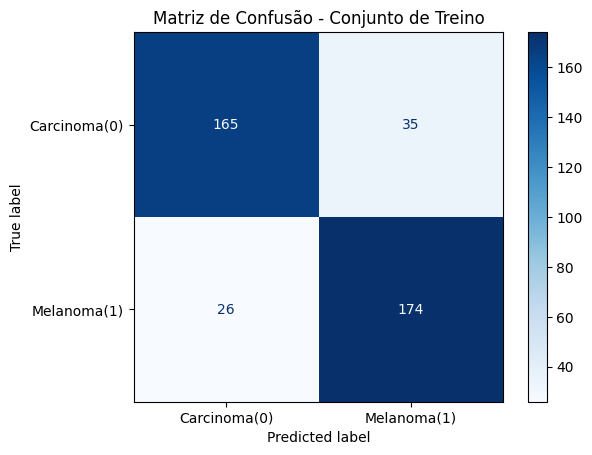

------------------------------
--- Métricas: Conjunto de Teste ---
Acurácia:  77.00%
Precisão:  75.47%
Revocação: 80.00%
F1-Score:  77.67%

Matriz de Confusão:


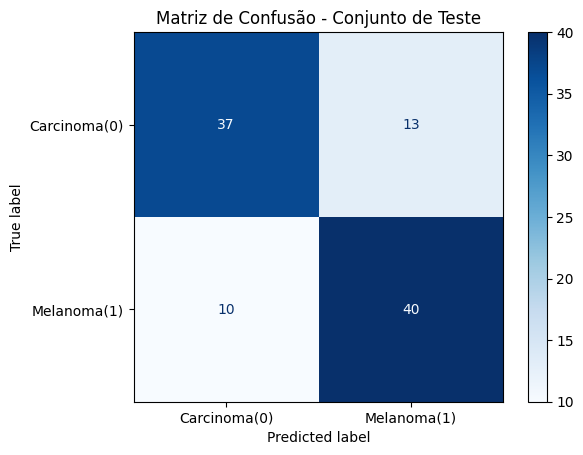

------------------------------


In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features)
test_features_scaled = scaler.transform(test_features)

k = 5
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(train_features_scaled, labels_train)

def avaliar_modelo(features, labels_true, titulo):
    labels_pred = knn.predict(features)

    acc = accuracy_score(labels_true, labels_pred)
    prec = precision_score(labels_true, labels_pred)
    rec = recall_score(labels_true, labels_pred)
    f1 = f1_score(labels_true, labels_pred)
    cm = confusion_matrix(labels_true, labels_pred)

    print(f"--- Métricas: {titulo} ---")
    print(f"Acurácia:  {acc:.2%}")
    print(f"Precisão:  {prec:.2%}")
    print(f"Revocação: {rec:.2%}")
    print(f"F1-Score:  {f1:.2%}")
    print("\nMatriz de Confusão:")

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Carcinoma(0)', 'Melanoma(1)'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Matriz de Confusão - {titulo}')
    plt.show()
    print("-" * 30)

avaliar_modelo(train_features_scaled, labels_train, "Conjunto de Treino")
avaliar_modelo(test_features_scaled, labels_test, "Conjunto de Teste")

**c)** Tente plotar os resultados da classificação usando os atributos 2 a 2 como eixos (por exemplo, os valores de variância no eixo y e os valores de média no eixo x). Utilize a função [scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) do matplotlib, já demonstrada no início da Parte 3 deste notebook. As amostras de treinamento devem ser plotadas com pontos circulares, enquanto as amostras de teste devem ser plotadas com pontos cruzados. Comente os resultados obtidos.

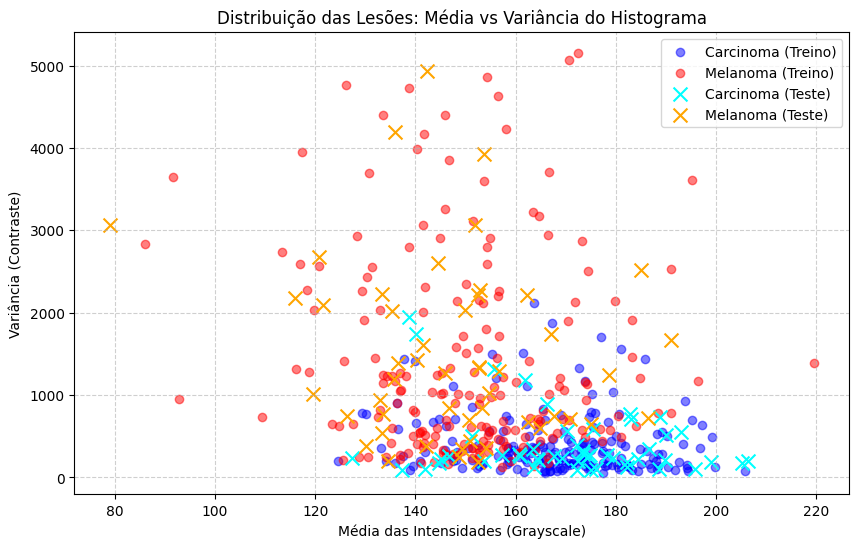

In [10]:
import matplotlib.pyplot as plt

idx_x = 0
idx_y = 8

plt.figure(figsize=(10, 6))

for cl, color, label in zip([0, 1], ['blue', 'red'], ['Carcinoma (Treino)', 'Melanoma (Treino)']):
    mask = np.array(labels_train) == cl
    plt.scatter(train_features[mask, idx_x],
                train_features[mask, idx_y],
                c=color, marker='o', alpha=0.5, label=label)

for cl, color, label in zip([0, 1], ['cyan', 'orange'], ['Carcinoma (Teste)', 'Melanoma (Teste)']):
    mask = np.array(labels_test) == cl
    plt.scatter(test_features[mask, idx_x],
                test_features[mask, idx_y],
                c=color, marker='x', s=100, label=label)

plt.title('Distribuição das Lesões: Média vs Variância do Histograma')
plt.xlabel('Média das Intensidades (Grayscale)')
plt.ylabel('Variância (Contraste)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


Média maior e variância menor -> Carcinoma(treino)
Média menor e variância maior -> Melanoma(treino)
Com isso os testes foram classificados de acordo com sua média e variância (features)

**d)** Comente os resultados obtidos: Você está satisfeito com o resultado? O que você pode inferir do seu classificador ao observar as métricas obtidas? Qual o erro mais frequente? Quais modificações poderiam ser feitas para tentar obter melhores resultados?

Resposta: Não estou satisfeito com o resultado. O uso de estatísticas globais de histogramas ignora features como geometria da lesão, assimetria e irregularidade das bordas. Ao observar as métricas obtidas, concluímos que se houver uma grande diferença entre a acurácia de treino e a de teste, o modelo estará com overfitting. No gráfico de dispersão, amostras que têm iluminação parecida com melanomas confundem o modelo facilmente. A sobreposição das classes no gráfico 2D sugere que os atributos escolhidos não possuem alto poder discriminatório. Ou seja, as assinaturas de contraste e brilho de ambas as lesões são numericamente próximas. O erro mais frequente é o Falso Negativo, pois o modelo classifica um Melanoma(1) como Carcinoma(0), de acordo com a matriz de confusão no quadrante inferior esquerdo. Modificações para Melhores Resultados: nos atributos obter textura, calcular circularidade da lesão. No tratamento da imagem, criar uma máscara para remover o fundo e calcular o histograma apenas da lesão. Aplicar filtros de realce de borda para destacar irregularidades.

### Exercício 3.2

Tente melhorar os resultados de classificação. Algumas sugestões:

- Redimensione as imagens para um tamanho menor **(14, 14)**, isso pode deixar os atributos menos suceptíveis a ruídos e detalhes, focando a classificação em características mais gerais;
- Altere o valor de vizinhos k;
- Em problemas de classificação, especialmente quando temos poucas amostras e muitos atributos, temos o "mal da dimensionalidade". A seleção de atributos pode ser utilizada para contornar esse problema e remover atributos reduntantes (correlacionados) ou irrelevantes. Você pode escolher atributos aleatoriamente, fazer uma análise estatística dos atributos correlacionados, ou ainda fazer uma análise visual. Pode também usar técnicas específicas de seleção de atributos ([feature selection](https://scikit-learn.org/stable/modules/feature_selection.html#feature-selection)).

Extraindo features...
Features extraídas - Treino: (400, 9), Teste: (100, 9)

Testando diferentes números de features...
Features: 3, Acurácia CV: 0.6800
Features: 5, Acurácia CV: 0.7400
Features: 7, Acurácia CV: 0.7400
Features: 10, Acurácia CV: 0.7425
Features: 15, Acurácia CV: 0.7425
Features: 20, Acurácia CV: 0.7425

Melhor número de features: 10
Features selecionadas - Treino: (400, 9), Teste: (100, 9)

Encontrando melhor valor de k...


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=10 is greater than n_features=9. All the features will be returned.
  warnings.warn(


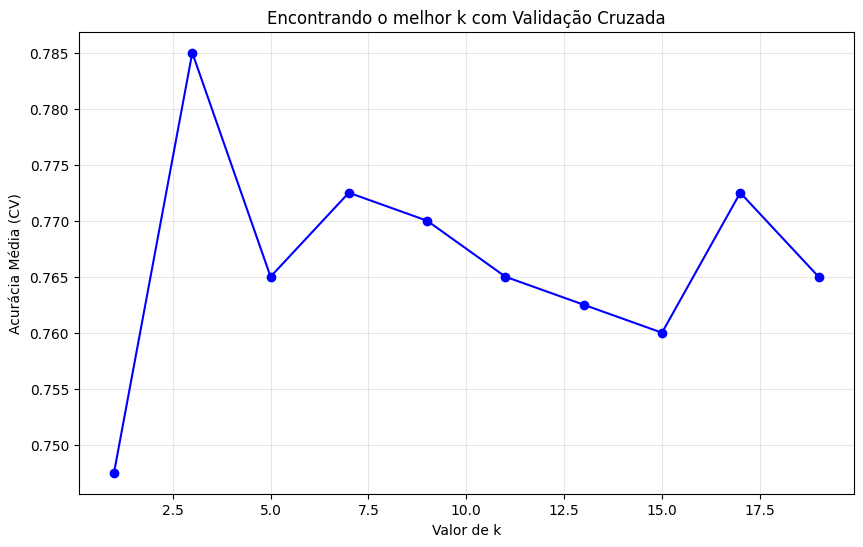

Melhor k encontrado: 3 com acurácia de 0.7850

Testando diferentes configurações...
Config: Padrão - Acurácia: 0.7400
Config: Pesos por distância - Acurácia: 0.7400
Config: k=5 uniform - Acurácia: 0.7700
Config: k=5 distância - Acurácia: 0.7700
Config: k=3 uniform - Acurácia: 0.7400

Melhor configuração: k=5, weights=uniform

=== KNN Otimizado (k=5, weights=uniform, 10-Best Features) ===
Acurácia: 0.7700

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.80      0.72      0.76        50
           1       0.75      0.82      0.78        50

    accuracy                           0.77       100
   macro avg       0.77      0.77      0.77       100
weighted avg       0.77      0.77      0.77       100



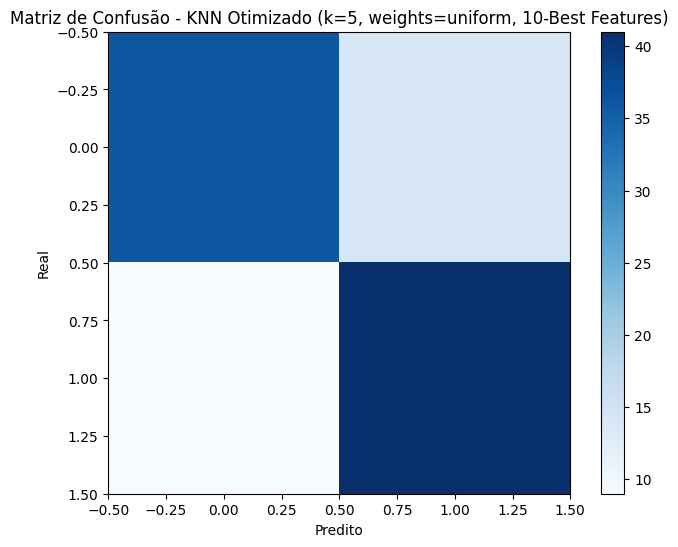

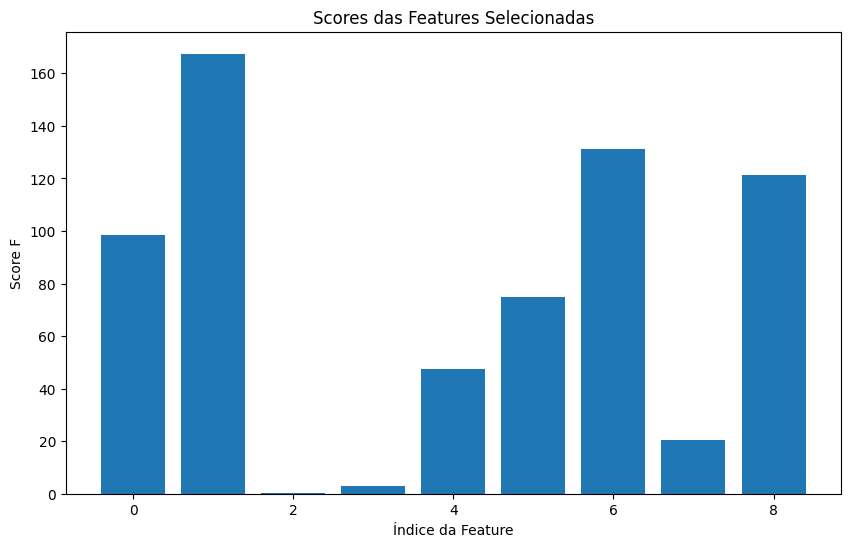

In [15]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

def avaliar_modelo(X_test, y_test, nome_modelo):
    """Avalia o modelo e imprime métricas"""
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

    # Fazer predições
    y_pred = knn_v2.predict(X_test)

    # Calcular acurácia
    acc = accuracy_score(y_test, y_pred)
    print(f"\n=== {nome_modelo} ===")
    print(f"Acurácia: {acc:.4f}")
    print("\nRelatório de Classificação:")
    print(classification_report(y_test, y_pred))

    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Matriz de Confusão - {nome_modelo}')
    plt.colorbar()
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.show()

    return acc

# 1. Redimensionamento das Imagens (Downsampling)
# Reduzir para 14x14 ajuda a suavizar ruídos e focar na distribuição global de tons.
def extrair_features_otimizado(lista_imagens):
    features = []
    for img_rgb in lista_imagens:
        # Verificar tipo da imagem
        if isinstance(img_rgb, str):
            img_pil = Image.open(img_rgb)
        else:
            # Converter para PIL para redimensionar facilmente
            img_pil = Image.fromarray(img_rgb).resize((14, 14), Image.Resampling.LANCZOS)

        # Converter para Grayscale
        img_gray = np.array(img_pil.convert("L"))

        # Histograma e Estatísticas
        hist, _ = np.histogram(img_gray, bins=256, range=(0, 255))
        features.append(histstat(hist))
    return np.array(features)

# Função para encontrar o melhor k
def encontrar_melhor_k(X_train, y_train, k_range=range(1, 21, 2)):
    """Encontra o melhor valor de k usando validação cruzada"""
    k_scores = []

    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
        k_scores.append(scores.mean())

    # Plotar resultados
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, k_scores, 'bo-')
    plt.xlabel('Valor de k')
    plt.ylabel('Acurácia Média (CV)')
    plt.title('Encontrando o melhor k com Validação Cruzada')
    plt.grid(True, alpha=0.3)
    plt.show()

    best_k = k_range[np.argmax(k_scores)]
    print(f"Melhor k encontrado: {best_k} com acurácia de {max(k_scores):.4f}")
    return best_k

# ===== EXECUÇÃO PRINCIPAL =====
# Assumindo que você já tem os dados carregados
# images_train, images_test, labels_train, labels_test

# Extrair novas features com imagens 14x14
print("Extraindo features...")
train_features_v2 = extrair_features_otimizado(images_train)
test_features_v2 = extrair_features_otimizado(images_test)

print(f"Features extraídas - Treino: {train_features_v2.shape}, Teste: {test_features_v2.shape}")

# 2. Seleção de Atributos (Feature Selection)
# Vamos usar o SelectKBest com o teste F de ANOVA
# Vamos testar diferentes números de features
print("\nTestando diferentes números de features...")
n_features_options = [3, 5, 7, 10, 15, 20]
feature_scores = []

for n in n_features_options:
    selector_temp = SelectKBest(score_func=f_classif, k=min(n, train_features_v2.shape[1]))
    X_train_temp = selector_temp.fit_transform(train_features_v2, labels_train)

    # Avaliar com k temporário
    knn_temp = KNeighborsClassifier(n_neighbors=5)
    scores = cross_val_score(knn_temp, X_train_temp, labels_train, cv=5)
    feature_scores.append(scores.mean())
    print(f"Features: {n}, Acurácia CV: {scores.mean():.4f}")

# Selecionar o melhor número de features
best_n_features = n_features_options[np.argmax(feature_scores)]
print(f"\nMelhor número de features: {best_n_features}")

# Aplicar seleção de features
selector = SelectKBest(score_func=f_classif, k=best_n_features)
train_features_selected = selector.fit_transform(train_features_v2, labels_train)
test_features_selected = selector.transform(test_features_v2)

print(f"Features selecionadas - Treino: {train_features_selected.shape}, Teste: {test_features_selected.shape}")

# 3. Normalização
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_features_selected)
test_scaled = scaler.transform(test_features_selected)

# 4. Encontrar o melhor valor de k
print("\nEncontrando melhor valor de k...")
best_k = encontrar_melhor_k(train_scaled, labels_train)

# 5. Testando diferentes configurações de k
print("\nTestando diferentes configurações...")
configuracoes = [
    (best_k, 'uniform', 'Padrão'),
    (best_k, 'distance', 'Pesos por distância'),
    (best_k + 2, 'uniform', f'k={best_k+2} uniform'),
    (best_k + 2, 'distance', f'k={best_k+2} distância'),
    (max(3, best_k - 2), 'uniform', f'k={max(3, best_k-2)} uniform'),
]

melhor_acc = 0
melhor_config = None

for k, weights, desc in configuracoes:
    knn_v2 = KNeighborsClassifier(n_neighbors=k, weights=weights)
    knn_v2.fit(train_scaled, labels_train)
    acc = knn_v2.score(test_scaled, labels_test)
    print(f"Config: {desc} - Acurácia: {acc:.4f}")

    if acc > melhor_acc:
        melhor_acc = acc
        melhor_config = (k, weights)

# Treinar modelo final com melhor configuração
k_otimo, weights_otimo = melhor_config
print(f"\nMelhor configuração: k={k_otimo}, weights={weights_otimo}")

knn_v2 = KNeighborsClassifier(n_neighbors=k_otimo, weights=weights_otimo)
knn_v2.fit(train_scaled, labels_train)

# Avaliação final
avaliar_modelo(test_scaled, labels_test, f"KNN Otimizado (k={k_otimo}, weights={weights_otimo}, {best_n_features}-Best Features)")

# Visualizar scores das features selecionadas
feature_scores = selector.scores_[selector.get_support()]
plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_scores)), feature_scores)
plt.xlabel('Índice da Feature')
plt.ylabel('Score F')
plt.title('Scores das Features Selecionadas')
plt.show()

## Parte 4 - Utilizando atributos de histograma de imagens coloridas (opicional para EA979)

Note que, ao realizar a transformação das imagens coloridas para imagens em escala de cinza na Parte 3 deste notebook, estamos desconsiderando características e informações das imagens com potencial para ajudar no processo de classificação.

### Exercício 4.1

Repita o processo de classificação do dataset de imagens dermatoscópicas, mas desta vez utilizando atributos de histograma extraídos diretamente das imagens coloridas (sem transformá-las para escala de cinza). Explique como a extração de atributos foi realizada e comente sobre os resultados obtidos. Lembre-se de tentar aplicar também as modificações utilizadas no exercício 3.2 para melhorar os resultados de classificação. Alguma das bandas da imagem se mostrou mais eficaz para a classificação? Os resultados de classificação foram melhores ou piores em relação a utilizar as imagens em escala de cinza? Comente.

In [ ]:
# Seu código aqui

## Parte 5 - Explorando atributos de textura (opicional para EA979)

Além dos atributos de histograma, existem diversos outros tipos de atributos que podem ser extraídos de imagens digitais, como os atributos de textura, por exemplo. No processamento de imagens, a textura pode ser definida em função da variação espacial da intensidade dos pixels em uma região da imagem. Os atributos de textura são úteis para caracterizar padrões em uma imagem, como rugosidade, suavidade, granulosidade, entre outros. Assim, a análise de textura desempenha um papel importante em casos de visão computacional, como reconhecimento de objetos, detecção de defeitos de superfície, reconhecimento de padrões, análise de imagens médicas, etc.

**Para saber mais sobre atributos de textura, verifique os materiais de apoio disponibilizados no classroom.**

### Exercício 5.1

Extraia atributos de textura (como [GLCM](https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_glcm.html), por exemplo) e repita a classificação. Comente sobre o método de extração de atributos escolhido (como funciona? quais seus parâmetros? que atributos consegue extrair?) e os resultados obtidos.

In [ ]:
# Seu código aqui